In [13]:
import pandas as pd
import sqlite3
import numpy as np
import time
import os
import requests
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle, Arc
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from nba_api.stats.static import players
from nba_api.stats.endpoints import commonplayerinfo
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import teams
from scipy.optimize import minimize
import statsmodels.api as sm


For our results, we will be comparing the change in center performance with the trend for the overall league. First, we need to import our datasets.

In [2]:
shot_loc_df = pd.read_csv('shot_loc.csv')
center_loc_df = pd.read_csv('center_loc.csv')

In [3]:
#We will now create a function which will draw the basketball court for our visualization of the year by year shots for both groups.
def draw_court(ax=None, color='black', lw=1.5):
    if ax is None:
        ax = plt.gca()

    # Hoop
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    # Backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    # Paint
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    # Free throw arcs
    top_ft = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    bottom_ft = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    # Restricted zone
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    # Three point line
    corner_three_l = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_r = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    # Center court
    center_outer = Arc((0, 422.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color)
    # Half court line
    outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False)

    court_elements = [hoop, backboard, outer_box, inner_box, top_ft, bottom_ft,
                      restricted, corner_three_l, corner_three_r, three_arc,
                      center_outer, outer_lines]

    for element in court_elements:
        ax.add_patch(element)

    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    ax.set_aspect('equal')
    return ax

We will now create a gif comparing all shots vs. center shots

In [4]:
years = sorted(set(shot_loc_df['YEAR'].unique()) & set(center_loc_df['YEAR'].unique()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_facecolor('#1a2e4a')

def animate(i):
    ax1.clear()
    ax2.clear()
    year = years[i]
    
    # Left: all players
    year_all = shot_loc_df[shot_loc_df['YEAR'] == year]
    ax1.hexbin(year_all.LOC_X, year_all.LOC_Y, gridsize=100,
               cmap='plasma', norm=LogNorm(), zorder=1)
    draw_court(ax=ax1, color='white', lw=1.5)
    ax1.set_title(f"All Players — {year}", fontsize=14, color='white')
    ax1.set_facecolor('#1a2e4a')
    ax1.tick_params(colors='white')
    ax1.spines[:].set_color('white')
    ax1.set_xlim(-250, 250)
    ax1.set_ylim(-47.5, 422.5)
    
    # Right: centers only
    year_centers = center_loc_df[center_loc_df['YEAR'] == year]
    ax2.hexbin(year_centers.LOC_X, year_centers.LOC_Y, gridsize=100,
               cmap='plasma', norm=LogNorm(), zorder=1)
    draw_court(ax=ax2, color='white', lw=1.5)
    ax2.set_title(f"Centers Only — {year}", fontsize=14, color='white')
    ax2.set_facecolor('#1a2e4a')
    ax2.tick_params(colors='white')
    ax2.spines[:].set_color('white')
    ax2.set_xlim(-250, 250)
    ax2.set_ylim(-47.5, 422.5)
    
    fig.suptitle(f"Shot Density Comparison — {year}", fontsize=18, color='white', y=0.98)

anim = FuncAnimation(fig, animate, frames=len(years), interval=1500, repeat=True)
anim.save('shot_density_comparison.gif', writer=PillowWriter(fps=1), 
          savefig_kwargs={'facecolor': '#1a2e4a'})
plt.close()

In [5]:
shot_loc_df['IS_THREE'] = (shot_loc_df['SHOT_TYPE'] == '3PT Field Goal').astype(int)
center_loc_df['IS_THREE'] = (center_loc_df['SHOT_TYPE'] == '3PT Field Goal').astype(int)

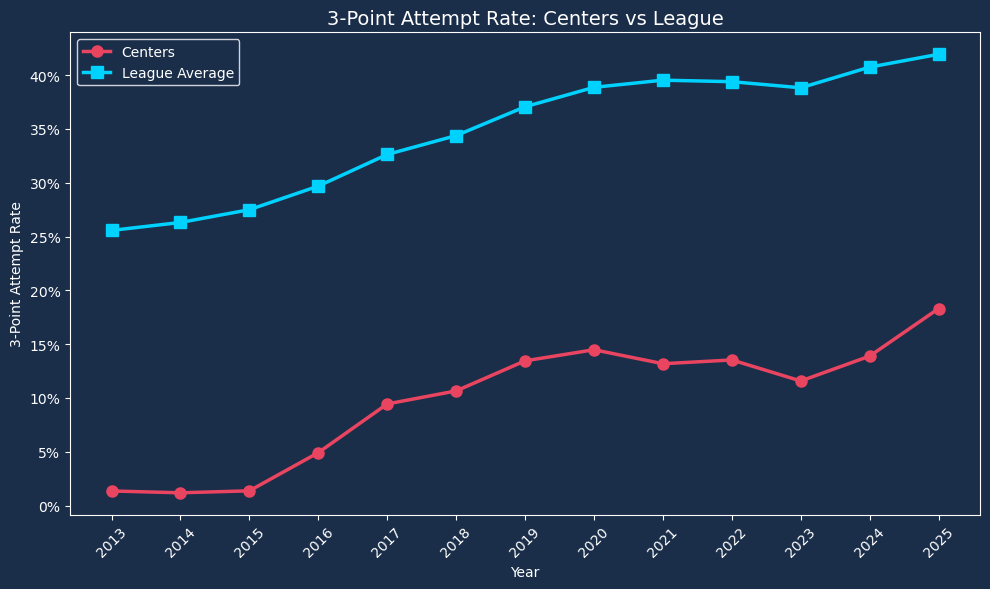

In [6]:
center_rate = center_loc_df.groupby('YEAR')['IS_THREE'].mean()
league_rate = shot_loc_df.groupby('YEAR')['IS_THREE'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1a2e4a')
ax.set_facecolor('#1a2e4a')

ax.plot(center_rate.index, center_rate.values, color='#e94560', linewidth=2.5, 
        marker='o', markersize=8, label='Centers')
ax.plot(league_rate.index, league_rate.values, color='#00d2ff', linewidth=2.5, 
        marker='s', markersize=8, label='League Average')

ax.set_title("3-Point Attempt Rate: Centers vs League", fontsize=14, color='white')
ax.set_xlabel("Year", color='white')
ax.set_ylabel("3-Point Attempt Rate", color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('white')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xticks(center_rate.index)
ax.set_xticklabels(center_rate.index, rotation=45)
ax.legend(facecolor='#1a2e4a', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

We are now going to perform a parallelism test on the 3-point attempt rate comparing the increase in shots taken by centers and the increase in the league as a whole.

In [11]:
center_ids = center_loc_df['PLAYER_NAME'].unique()
shot_loc_df['IS_CENTER'] = shot_loc_df['PLAYER_NAME'].isin(center_ids).astype(int)

In [14]:
shot_loc_df['IS_THREE'] = (shot_loc_df['SHOT_TYPE'] == '3PT Field Goal').astype(int)
shot_loc_df['YEAR_X_CENTER'] = shot_loc_df['YEAR'] * shot_loc_df['IS_CENTER']

X = sm.add_constant(shot_loc_df[['YEAR', 'IS_CENTER', 'YEAR_X_CENTER']])
model = sm.Logit(shot_loc_df['IS_THREE'], X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.626962
         Iterations 34
                           Logit Regression Results                           
Dep. Variable:               IS_THREE   No. Observations:              2510338
Model:                          Logit   Df Residuals:                  2510334
Method:                           MLE   Df Model:                            3
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                 0.03231
Time:                        20:22:33   Log-Likelihood:            -1.5739e+06
converged:                       True   LL-Null:                   -1.6264e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -122.9166      0.792   -155.192      0.000    -124.469    -121.364
YEAR              0

From these results, we can see the log odds of centers shooting three pointers increases by 0.098 on top of the whole league's increase of 0.061. Centers are adopting the three-point shot at a significantly faster rate relative to the rest of the league. 

In [16]:
center_rate = center_loc_df.groupby('YEAR')['IS_THREE'].mean()
league_rate = shot_loc_df.groupby('YEAR')['IS_THREE'].mean()

gap = league_rate - center_rate
gap_df = pd.DataFrame({'Center': center_rate, 'League': league_rate, 'Gap': gap})
gap_df['Center'] = gap_df['Center'].map('{:.1%}'.format)
gap_df['League'] = gap_df['League'].map('{:.1%}'.format)
gap_df['Gap'] = gap_df['Gap'].map('{:.1%}'.format)
print(gap_df)

     Center League    Gap
YEAR                     
2013   1.4%  25.6%  24.2%
2014   1.2%  26.3%  25.1%
2015   1.4%  27.5%  26.1%
2016   4.9%  29.7%  24.8%
2017   9.4%  32.6%  23.2%
2018  10.7%  34.4%  23.7%
2019  13.5%  37.1%  23.6%
2020  14.5%  38.9%  24.4%
2021  13.2%  39.5%  26.3%
2022  13.5%  39.4%  25.9%
2023  11.6%  38.8%  27.2%
2024  13.9%  40.7%  26.9%
2025  18.3%  41.9%  23.6%


While the rate of 3 point field goal attempts has increased among centers relative to the league, the likelihood of a shot being a three pointer across the league is consistently between 23% and 28% higher than the likelihood a center will take a three point shot. We will create a test for parallelism to determine if there is a difference in slopes in the % increase of three pointers from centers than the rest of the league.

In [17]:
center_rate = center_loc_df.groupby('YEAR')['IS_THREE'].mean().reset_index()
center_rate.columns = ['YEAR', 'THREE_RATE']
center_rate['IS_CENTER'] = 1

league_rate = shot_loc_df.groupby('YEAR')['IS_THREE'].mean().reset_index()
league_rate.columns = ['YEAR', 'THREE_RATE']
league_rate['IS_CENTER'] = 0

combined = pd.concat([center_rate, league_rate], ignore_index=True)
combined['YEAR_X_CENTER'] = combined['YEAR'] * combined['IS_CENTER']

X = sm.add_constant(combined[['YEAR', 'IS_CENTER', 'YEAR_X_CENTER']])
model = sm.OLS(combined['THREE_RATE'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             THREE_RATE   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     356.7
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           8.48e-19
Time:                        20:41:57   Log-Likelihood:                 65.587
No. Observations:                  26   AIC:                            -123.2
Df Residuals:                      22   BIC:                            -118.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -28.8393      3.159     -9.128

From this test, we can see the IS_CENTER and YEAR_X_CENTER variables are statistically insignificant. This means the percent increase in shots from centers is parallel to the percent inrcease for the rest of the league. 

We will now create a function that can run both of these tests for different shot zones.

In [26]:
def parallelism_test(shot_loc_df, center_loc_df, zone):
    """
    Run both logistic and OLS parallelism tests for a given shot zone.
    Tests whether the proportion of shots from that zone is changing
    at the same rate for centers vs the league.
    """
    # Tag centers in league data
    center_names = center_loc_df['PLAYER_NAME'].unique()
    league_data = shot_loc_df.copy()
    league_data['IS_CENTER'] = league_data['PLAYER_NAME'].isin(center_names).astype(int)
    league_data['IS_ZONE'] = (league_data['SHOT_ZONE'] == zone).astype(int)
    league_data['YEAR_X_CENTER'] = league_data['YEAR'] * league_data['IS_CENTER']
    
    print(f"{'='*60}")
    print(f"Zone: {zone}")
    print(f"Total shots: {len(league_data):,}")
    print(f"Center shots: {league_data['IS_CENTER'].sum():,}")
    print(f"{'='*60}")
    
    # --- Logistic Regression (log-odds scale) ---
    print("\n--- Logistic Regression (Log-Odds Scale) ---\n")
    
    X = sm.add_constant(league_data[['YEAR', 'IS_CENTER', 'YEAR_X_CENTER']])
    logit_model = sm.Logit(league_data['IS_ZONE'], X).fit(disp=0)
    print(logit_model.summary())
    
    # --- OLS Regression (percentage scale) ---
    print(f"\n--- OLS Regression (Percentage Scale) ---\n")
    
    center_data = league_data[league_data['IS_CENTER'] == 1]
    non_center_data = league_data[league_data['IS_CENTER'] == 0]
    
    center_rate = center_data.groupby('YEAR')['IS_ZONE'].mean().reset_index()
    center_rate.columns = ['YEAR', 'ZONE_RATE']
    center_rate['IS_CENTER'] = 1
    
    league_rate = non_center_data.groupby('YEAR')['IS_ZONE'].mean().reset_index()
    league_rate.columns = ['YEAR', 'ZONE_RATE']
    league_rate['IS_CENTER'] = 0
    
    combined = pd.concat([center_rate, league_rate], ignore_index=True)
    combined['YEAR_C'] = combined['YEAR'] - combined['YEAR'].mean()
    combined['YEAR_C_X_CENTER'] = combined['YEAR_C'] * combined['IS_CENTER']
    
    X = sm.add_constant(combined[['YEAR_C', 'IS_CENTER', 'YEAR_C_X_CENTER']])
    ols_model = sm.OLS(combined['ZONE_RATE'], X).fit()
    print(ols_model.summary())
    
    # --- Summary ---
    print(f"\n{'='*60}")
    print("SUMMARY")
    print(f"{'='*60}")
    logit_interaction = logit_model.params['YEAR_X_CENTER']
    logit_p = logit_model.pvalues['YEAR_X_CENTER']
    ols_interaction = ols_model.params['YEAR_C_X_CENTER']
    ols_p = ols_model.pvalues['YEAR_C_X_CENTER']
    
    print(f"Logistic: interaction = {logit_interaction:.4f}, p = {logit_p:.4f}")
    print(f"  -> {'NOT parallel' if logit_p < 0.05 else 'Parallel'} on log-odds scale")
    print(f"OLS:      interaction = {ols_interaction:.4f}, p = {ols_p:.4f}")
    print(f"  -> {'NOT parallel' if ols_p < 0.05 else 'Parallel'} on percentage scale")

In [29]:
parallelism_test(shot_loc_df, center_loc_df, 'Above-the-Break Three')
parallelism_test(shot_loc_df, center_loc_df, 'Corner Three')
parallelism_test(shot_loc_df, center_loc_df, 'Mid-Range')
parallelism_test(shot_loc_df, center_loc_df, 'Restricted Area')
parallelism_test(shot_loc_df, center_loc_df, 'Paint')

Zone: Above-the-Break Three
Total shots: 2,510,338
Center shots: 200,921

--- Logistic Regression (Log-Odds Scale) ---



C:\Users\maxca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:                IS_ZONE   No. Observations:              2510338
Model:                          Logit   Df Residuals:                  2510334
Method:                           MLE   Df Model:                            3
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                 0.02248
Time:                        22:33:18   Log-Likelihood:            -1.4303e+06
converged:                      False   LL-Null:                   -1.4632e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -97.2887      0.845   -115.166      0.000     -98.944     -95.633
YEAR              0.0477      0.000    114.090      0.000       0.047       0.049
IS_CENTER      -208.6489      4.932    -

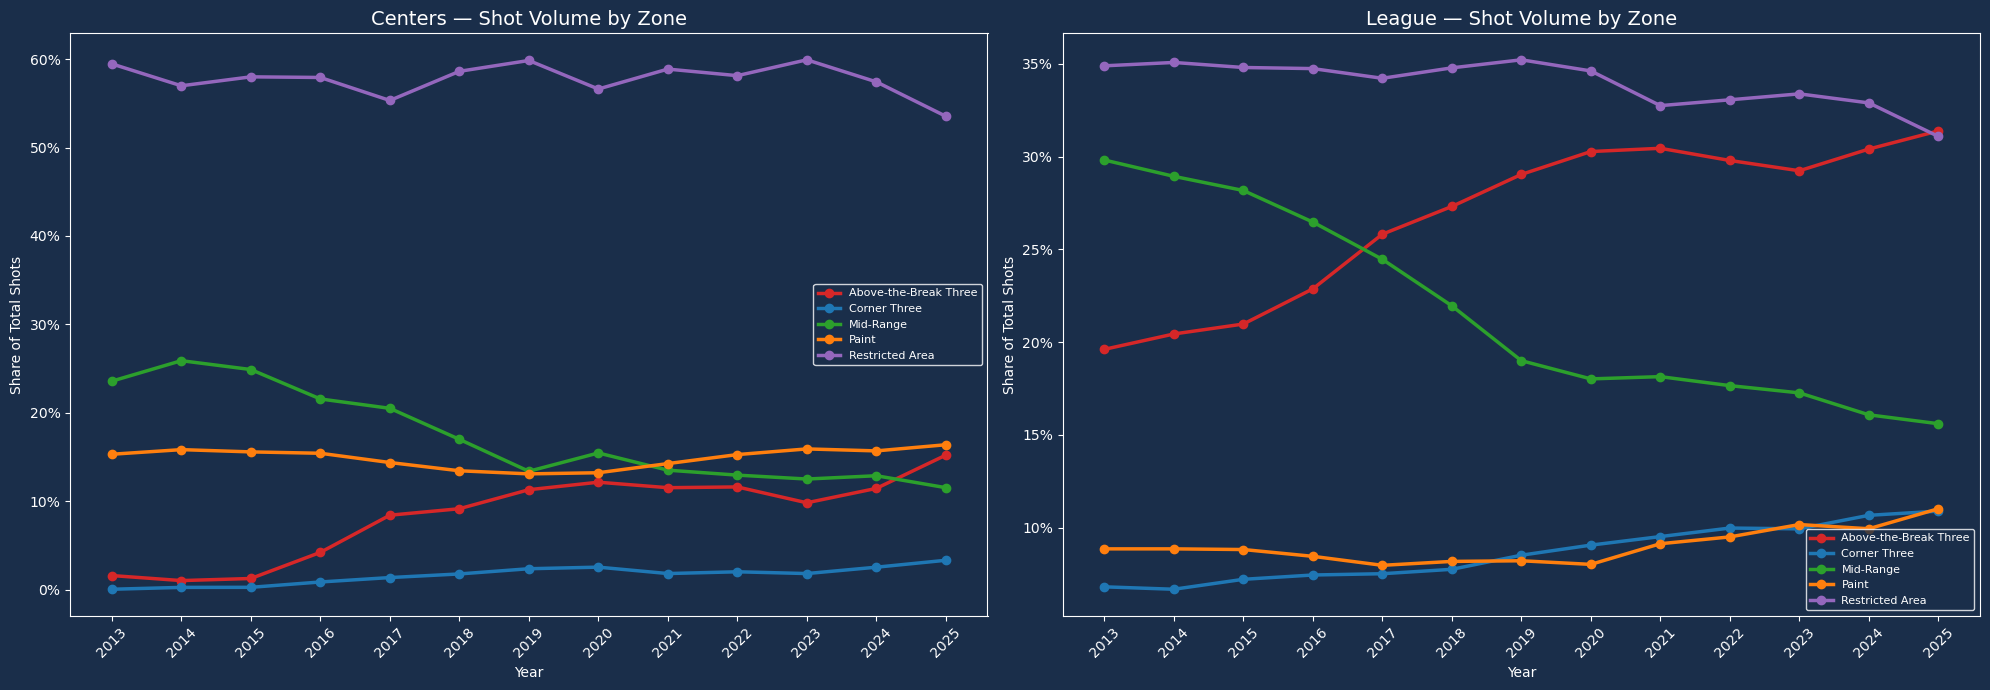

In [31]:
# Volume by zone for both groups
center_volume = center_loc_df.groupby(['YEAR', 'SHOT_ZONE']).size().unstack(fill_value=0)
center_volume = center_volume.div(center_volume.sum(axis=1), axis=0)

league_volume = shot_loc_df.groupby(['YEAR', 'SHOT_ZONE']).size().unstack(fill_value=0)
league_volume = league_volume.div(league_volume.sum(axis=1), axis=0)

zones = center_volume.columns
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.patch.set_facecolor('#1a2e4a')

# Left: centers
ax = axes[0]
ax.set_facecolor('#1a2e4a')
for zone, color in zip(zones, colors):
    ax.plot(center_volume.index, center_volume[zone], color=color, linewidth=2.5, marker='o', markersize=6, label=zone)
ax.set_title("Centers — Shot Volume by Zone", fontsize=14, color='white')
ax.set_ylabel("Share of Total Shots", color='white')
ax.set_xlabel("Year", color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('white')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xticks(center_volume.index)
ax.set_xticklabels(center_volume.index, rotation=45)
ax.legend(facecolor='#1a2e4a', edgecolor='white', labelcolor='white', fontsize=8)

# Right: league
ax = axes[1]
ax.set_facecolor('#1a2e4a')
for zone, color in zip(zones, colors):
    ax.plot(league_volume.index, league_volume[zone], color=color, linewidth=2.5, marker='o', markersize=6, label=zone)
ax.set_title("League — Shot Volume by Zone", fontsize=14, color='white')
ax.set_ylabel("Share of Total Shots", color='white')
ax.set_xlabel("Year", color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('white')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xticks(league_volume.index)
ax.set_xticklabels(league_volume.index, rotation=45)
ax.legend(facecolor='#1a2e4a', edgecolor='white', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('volume_comparison.png')
plt.show()